# One forecast-to-order workflow on an irregular calendar

A tea buyer can order on only three dates during an eleven-day planning window. Delivery takes one day. **How do the forecast, decision calendar, policy, and simulator work together?**

This example joins the pieces introduced earlier:

```text
DecisionSchedule + lead time → dated coverage window
observed demand + window → Smooth's cumulative forecast → stock target
schedule + target → OrderUpToPolicy → SimulationEngine
                  → validated events and evaluation
```

The schedule says *when a decision is allowed*. A fitted policy snapshot supplies the target available at that decision. The engine applies the policy, moves accepted orders through the delivery pipeline, serves demand, and records what happened.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from smooth import ES

from stockcast import ExplicitSchedule, InventoryStateDataFrame, OrderUpToPolicy, SimulationEngine
from stockcast.evaluation import InventoryEvaluator, avg_on_hand, fill_rate, order_units, validate_event_frame


## 1. Declare the demand path and order opportunities

These artificial observations are **uncensored demand**, not sales limited by stock. The first 24 days are available at the opening date. Eleven later days are held out for the inventory replay and become forecast history only after they occur. One daily row is one engine demand period.

In [3]:
sku = 'tea_250g'
frequency = 'D'
lead_time = 1
probability = 0.90
history_values = [5, 6, 4, 7, 6, 5, 8, 6, 5, 7, 6, 5,
                  7, 8, 5, 6, 7, 5, 6, 8, 7, 6, 5, 7]
future_values = [6, 7, 8, 5, 7, 9, 6, 8, 5, 7, 6]
opening_date = pd.Timestamp('2026-03-01')
history = pd.DataFrame({
    'date': pd.date_range(end=opening_date, periods=len(history_values), freq=frequency),
    'y': history_values,
})
held_out = pd.DataFrame({
    'unique_id': [sku] * len(future_values),
    'period': range(len(future_values)),  # Zero-based demand periods within this run.
    'date': pd.date_range(opening_date + pd.Timedelta(days=1), periods=len(future_values), freq=frequency),
    'y': future_values,
})
assert history.date.max() == opening_date
assert held_out.date.min() == opening_date + pd.Timedelta(days=1)
print('Opening date:', opening_date.date(), '| held-out demand periods:', len(held_out))
print(held_out[['period', 'date', 'y']].to_string(index=False))


Opening date: 2026-03-01 | held-out demand periods: 11
 period       date  y
      0 2026-03-02  6
      1 2026-03-03  7
      2 2026-03-04  8
      3 2026-03-05  5
      4 2026-03-06  7
      5 2026-03-07  9
      6 2026-03-08  6
      7 2026-03-09  8
      8 2026-03-10  5
      9 2026-03-11  7
     10 2026-03-12  6


An `ExplicitSchedule` lists the only demand periods at which an order can be requested. Period 0 is the first held-out day; periods 3 and 7 are later opportunities. A decision happens **before that period's demand**, using observations through the preceding date. A decision opportunity can still produce a zero order.

In [4]:
decision_periods = (0, 3, 7)
schedule = ExplicitSchedule(decision_periods)
assert [t for t in range(len(held_out)) if schedule.should_decide(t)] == list(decision_periods)
print('Decision schedule:', schedule.to_manifest())
print(held_out.loc[held_out.period.isin(decision_periods), ['period', 'date']].to_string(index=False))


Decision schedule: {'type': 'explicit', 'periods': [0, 3, 7]}
 period       date
      0 2026-03-02
      3 2026-03-05
      7 2026-03-09


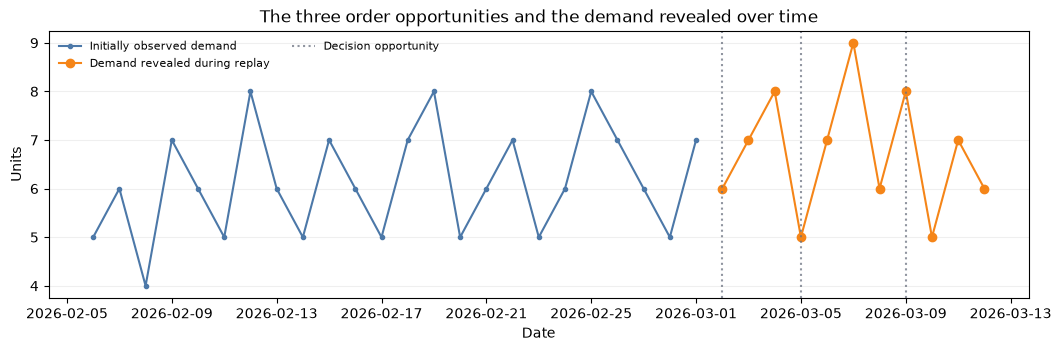

In [5]:
fig, ax = plt.subplots(figsize=(10.5, 3.4), layout='constrained')
ax.plot(history.date, history.y, marker='.', color='#4C78A8', label='Initially observed demand')
ax.plot(held_out.date, held_out.y, marker='o', color='#F58518', label='Demand revealed during replay')
for t in decision_periods:
    day = held_out.loc[held_out.period.eq(t), 'date'].iloc[0]
    ax.axvline(day, color='#6B7280', linestyle=':', alpha=.75,
               label='Decision opportunity' if t == decision_periods[0] else None)
ax.set(title='The three order opportunities and the demand revealed over time', xlabel='Date', ylabel='Units')
ax.legend(frameon=False, fontsize=8, ncol=2)
ax.grid(axis='y', alpha=.2)
plt.show()


## 2. Match each forecast to its decision window

For a decision at period `t`, let `u` be the next opportunity. With one-day delivery, today's stock position must cover `H = (u − t) + 1` demand periods: the next order cannot arrive until period `u + 1`. The first two windows are therefore four and five days. At the final decision there is no later opportunity in this run, so we **explicitly** cover the four remaining demand periods through day 11. The last choice is a finite run assumption, not a horizon inferred by Stockcast.

Smooth fits a separate `ES(model='ANN')` forecast at each information cutoff. Its direct `cumulative=True` upper bound is the target; we never add daily marginal upper bounds. For the plot only, we add daily forecast **means** to show the expected running total. Smooth's normal-error assumption and the chosen 90% probability are illustrative, not validated for a real product.

In [6]:
window_rows = []
for t in decision_periods:
    next_t = schedule.next_decision_period(t)
    horizon = (next_t - t + lead_time) if next_t is not None else len(held_out) - t
    origin = opening_date + pd.Timedelta(days=t)
    window_rows.append({
        'decision_period': t,
        'next_opportunity': str(next_t) if next_t is not None else 'end of run',
        'coverage_days': horizon,
        'forecast_origin': origin,
        'target_end_date': origin + pd.Timedelta(days=horizon),
    })
windows = pd.DataFrame(window_rows)
assert windows.coverage_days.tolist() == [4, 5, 4]
print('Decision windows (one-day delivery lead time)')
print(windows.to_string(index=False))


Decision windows (one-day delivery lead time)
 decision_period next_opportunity  coverage_days forecast_origin target_end_date
               0                3              4      2026-03-01      2026-03-05
               3                7              5      2026-03-04      2026-03-09
               7       end of run              4      2026-03-08      2026-03-12


The window table is a forecasting requirement, not an order. At each origin below, we fit only demand already observed, request a direct upper bound for that window's **cumulative** demand, and round it up to whole stock units. The running mean path is used only to make the forecast visible in the plot.

In [7]:
forecast_rows = []
forecast_paths = []
for window in windows.itertuples(index=False):
    t, horizon, origin = window.decision_period, window.coverage_days, window.forecast_origin
    observed_so_far = held_out.loc[held_out.period.lt(t), ['date', 'y']]
    available = pd.concat([history, observed_so_far], ignore_index=True)
    assert available.date.max() == origin
    assert available.date.max() < held_out.loc[held_out.period.eq(t), 'date'].iloc[0]

    model = ES(model='ANN')
    model.fit(available.y)
    daily = model.predict(h=horizon, interval='prediction',
                          level=probability, side='upper', cumulative=False)
    cumulative = model.predict(h=horizon, interval='prediction',
                               level=probability, side='upper', cumulative=True)
    upper = float(cumulative.upper.iloc[-1, 0])
    assert np.isfinite(upper) and upper >= 0
    target_units = int(np.ceil(upper))
    forecast_dates = pd.date_range(origin + pd.Timedelta(days=1), periods=horizon, freq=frequency)
    assert forecast_dates[-1] == window.target_end_date
    forecast_paths.append(pd.DataFrame({
        'decision_period': t, 'forecast_origin': origin,
        'date': forecast_dates, 'cumulative_mean': daily.mean.to_numpy().cumsum(),
    }))
    forecast_rows.append({
        'decision_period': t, 'observed_through': available.date.max(),
        'fit_rows': len(available), 'cumulative_upper_90': upper,
        'stock_target': target_units,
    })
forecasts = pd.DataFrame(forecast_rows)
paths = pd.concat(forecast_paths, ignore_index=True)
assert forecasts.fit_rows.tolist() == [24, 27, 31]
print('Forecast information and targets')
print(forecasts.to_string(index=False, float_format=lambda value: f'{value:.2f}'))


Forecast information and targets
 decision_period observed_through  fit_rows  cumulative_upper_90  stock_target
               0       2026-03-01        24                27.42            28
               3       2026-03-04        27                34.39            35
               7       2026-03-08        31                28.26            29


Now bind each externally calculated target to the same `OrderUpToPolicy` configuration. The schedule and lead time stay fixed; the forecast origin, target value, coverage length, and end date change. Stockcast validates those declarations when fitting and again against the actual decision windows before the run.

In [8]:
policies = {}
for window in windows.itertuples(index=False):
    t = window.decision_period
    target_units = int(forecasts.loc[forecasts.decision_period.eq(t), 'stock_target'].iloc[0])
    target = pd.DataFrame({
        'unique_id': [sku], 'target': [target_units],
        'target_end': [window.target_end_date],
    })
    policies[t] = OrderUpToPolicy(
        lead_time=lead_time, schedule=schedule, service_level=probability,
        allow_backorders=False,
    ).fit(
        target, target_column='target', target_probability=probability,
        protection_horizon=window.coverage_days, target_source='external_direct',
        forecast_origin=window.forecast_origin, forecast_frequency=frequency,
        target_end_date_column='target_end',
    )
print('Fitted snapshots:', sorted(policies))
print('Opening target metadata:', policies[0].get_target_metadata())


Fitted snapshots: [0, 3, 7]
Opening target metadata: {'representation': 'direct_protection_period_target', 'target_probability': 0.9, 'protection_horizon': 4, 'target_source': 'external_direct', 'forecast_origin': '2026-03-01T00:00:00', 'forecast_frequency': 'D', 'target_end_date': '2026-03-05T00:00:00'}


The target is a **stock-position level**. At each allowed date, `OrderUpToPolicy` will request `max(0, target − inventory position)`, accounting for physical stock and any order still in transit. `policy_schedule` supplies the later fitted target snapshots; it does not create new decision dates. The explicit `schedule` does that.

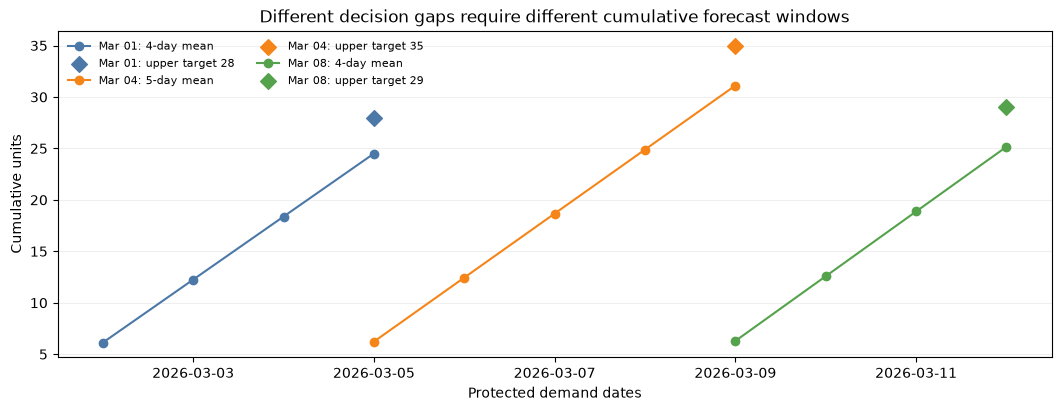

In [9]:
colors = {0: '#4C78A8', 3: '#F58518', 7: '#54A24B'}
fig, ax = plt.subplots(figsize=(10.5, 4), layout='constrained')
for t in decision_periods:
    path = paths.loc[paths.decision_period.eq(t)]
    target = forecasts.loc[forecasts.decision_period.eq(t), 'stock_target'].iloc[0]
    origin = windows.loc[windows.decision_period.eq(t), 'forecast_origin'].iloc[0]
    ax.plot(path.date, path.cumulative_mean, marker='o', color=colors[t],
            label=f'{origin:%b %d}: {len(path)}-day mean')
    ax.scatter(path.date.iloc[-1], target, marker='D', s=64, color=colors[t], zorder=3,
               label=f'{origin:%b %d}: upper target {target}')
ax.set(title='Different decision gaps require different cumulative forecast windows',
       xlabel='Protected demand dates', ylabel='Cumulative units')
ax.legend(frameon=False, fontsize=8, ncol=2)
ax.grid(axis='y', alpha=.2)
plt.show()


## 3. Give the simulator the schedule, policies, and demand

Opening stock is an observed scenario input of four units, independent of the forecast. The engine receives the complete held-out demand table for a reproducible replay. It receives the initial fitted policy at period 0 and replacement **targets** at periods 3 and 7. Each forecast fit above used only demand that would already have been observed at its own decision date. The engine checks policy compatibility, timing, and target coverage before running; it never fits Smooth itself.

In [10]:
opening = InventoryStateDataFrame(
    [sku], max_lead_time=lead_time, allow_backorders=False,
).initialize_from_observed(
    pd.DataFrame({'unique_id': [sku], 'on_hand': [4.0]}),
    on_hand_column='on_hand', start_date=opening_date,
)
updates = {t: policies[t] for t in decision_periods[1:]}
result = SimulationEngine().run(
    policy=policies[0], policy_schedule=updates,
    demand_source=held_out, inventory=opening, n_periods=len(held_out),
    period_frequency=frequency, initial_decision='none',
    warmup_periods=0, scoring_periods=len(held_out), settlement_periods=0,
    order_during_settlement=False, demand_source_name='declared_heldout_tea_demand',
    random_seed=None,
)
print('Engine schedule:', result.run_manifest['run_settings']['decision_schedule'])
print('Target update periods:', result.run_manifest['run_settings']['policy_update_periods'])


Engine schedule: {'type': 'explicit', 'periods': [0, 3, 7]}
Target update periods: [3, 7]


## 4. Follow decisions into physical stock

The validated event ledger is the record of what the engine did. A scheduled decision is visible even if its requested order is zero. The order at period 0 enters the pipeline; with lead time one it is received **before period 1 demand**, not before period 0 demand. That first day can therefore have lost sales despite a positive opening order.

In [11]:
events = validate_event_frame(result.to_event_frame(window='all'))
periods = events.loc[events.event_type.eq('period')].copy()
columns = ['demand_period', 'date', 'decision_flag', 'target_level', 'demand',
           'order_quantity', 'received_units', 'fulfilled_units', 'lost_sales_units',
           'ending_on_hand', 'on_order_end']
print(periods[columns].to_string(index=False, float_format=lambda value: f'{value:.2f}'))
actual_decisions = periods.loc[periods.decision_flag, 'demand_period'].tolist()
assert actual_decisions == list(decision_periods)
by_period = periods.set_index('demand_period')
for t in decision_periods:
    assert np.isclose(by_period.loc[t + lead_time, 'received_units'],
                      by_period.loc[t, 'order_quantity'])
first, second = by_period.loc[0], by_period.loc[1]
assert first.received_units == 0 and first.lost_sales_units == 2
assert np.isclose(first.starting_on_hand + first.received_units - first.fulfilled_units,
                  first.ending_on_hand)
print(f'First day: {first.starting_on_hand:.0f} opening + {first.received_units:.0f} received '
      f'- {first.fulfilled_units:.0f} sold = {first.ending_on_hand:.0f} on hand; '
      f'{first.lost_sales_units:.0f} lost sales. The {first.order_quantity:.0f}-unit order '
      f'arrives next day.')


 demand_period       date  decision_flag  target_level  demand  order_quantity  received_units  fulfilled_units  lost_sales_units  ending_on_hand  on_order_end
             0 2026-03-02           True         28.00    6.00           24.00            0.00             4.00              2.00            0.00         24.00
             1 2026-03-03          False         28.00    7.00            0.00           24.00             7.00              0.00           17.00          0.00
             2 2026-03-04          False         28.00    8.00            0.00            0.00             8.00              0.00            9.00          0.00
             3 2026-03-05           True         35.00    5.00           26.00            0.00             5.00              0.00            4.00         26.00
             4 2026-03-06          False         35.00    7.00            0.00           26.00             7.00              0.00           23.00          0.00
             5 2026-03-07          False

The upper target and actual order have different meanings. The target covers a dated forecast window; the order fills the gap from inventory position at a decision. The next figure connects those decisions to later receipts and end-of-day stock. Vertical lines mark opportunities, including dates when the engine may choose to order nothing.

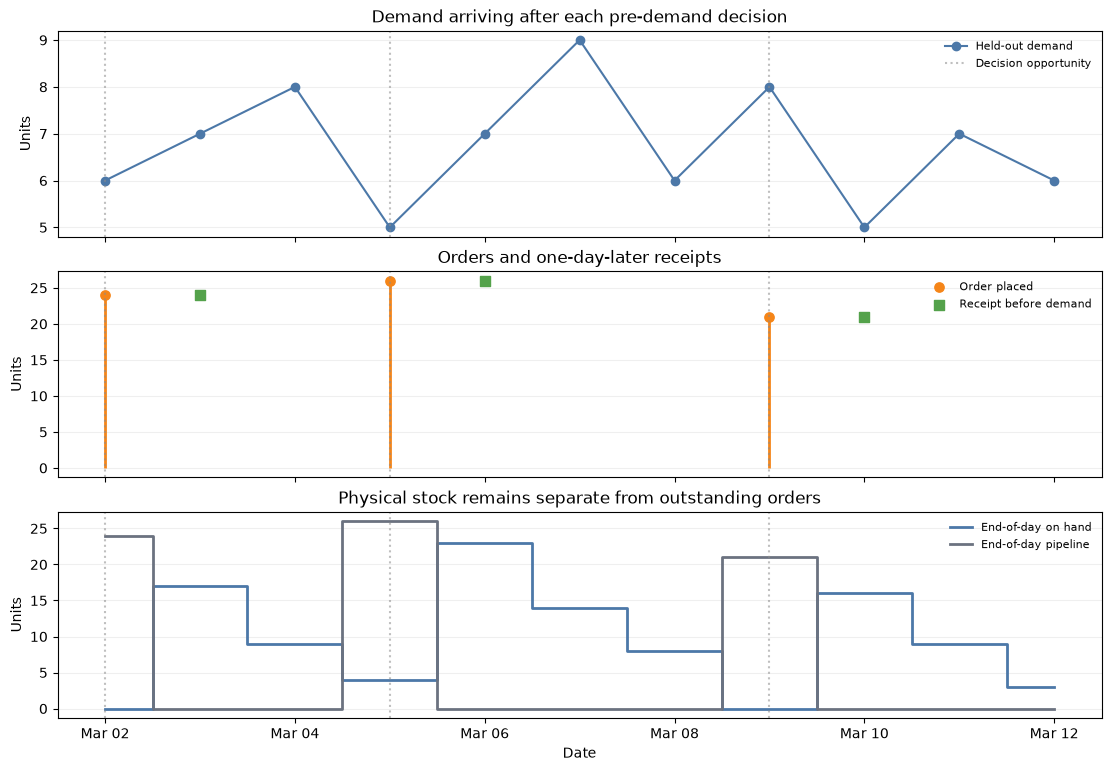

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7.6), sharex=True, layout='constrained')
axes[0].plot(periods.date, periods.demand, marker='o', color='#4C78A8', label='Held-out demand')
axes[0].set(title='Demand arriving after each pre-demand decision', ylabel='Units')
order_days = periods.loc[periods.order_quantity.gt(0)]
receipt_days = periods.loc[periods.received_units.gt(0)]
axes[1].vlines(order_days.date, 0, order_days.order_quantity, color='#F58518', linewidth=2)
axes[1].scatter(order_days.date, order_days.order_quantity, color='#F58518', s=45, label='Order placed')
axes[1].scatter(receipt_days.date, receipt_days.received_units, color='#54A24B', marker='s', s=45,
                label='Receipt before demand')
axes[1].set(title='Orders and one-day-later receipts', ylabel='Units')
axes[2].step(periods.date, periods.ending_on_hand, where='mid', color='#4C78A8',
             linewidth=2, label='End-of-day on hand')
axes[2].step(periods.date, periods.on_order_end, where='mid', color='#6B7280',
             linewidth=2, label='End-of-day pipeline')
axes[2].set(title='Physical stock remains separate from outstanding orders', ylabel='Units', xlabel='Date')
for ax in axes:
    for t in decision_periods:
        ax.axvline(by_period.loc[t, 'date'], color='0.55', linestyle=':', alpha=.55,
                   label='Decision opportunity' if ax is axes[0] and t == 0 else None)
    ax.grid(axis='y', alpha=.2)
axes[0].legend(frameon=False, fontsize=8)
axes[1].legend(frameon=False, fontsize=8)
axes[2].legend(frameon=False, fontsize=8)
axes[2].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.show()


## 5. Read the outcome without overstating it

Stockcast evaluates the **validated scoring events**, not the forecast model. These measures describe eleven artificial held-out days under the declared schedule, lead time, opening stock, and targets. A 90% predictive target is not a promise of 90% realized fill rate or an optimal order calendar.

In [13]:
metrics = InventoryEvaluator().fit(
    simulation_result=result, window='scoring',
).evaluate(metrics=[fill_rate, avg_on_hand, order_units], groupby=[])
print(metrics.to_string(index=False, float_format=lambda value: f'{value:.3f}'))
print('Scheduled decisions:', actual_decisions,
      '| positive orders:', int((periods.order_quantity > 0).sum()))


 fill_rate  avg_on_hand  order_units
     0.973        9.364       71.000
Scheduled decisions: [0, 3, 7] | positive orders: 3


## What the pieces each contributed

- **Smooth** estimated cumulative demand through each dated coverage window, using history available at that origin.
- **`ExplicitSchedule`** named the three opportunities and their next decision dates.
- **`policy_schedule`** selected a compatible fitted target when each later opportunity arrived.
- **`OrderUpToPolicy`** translated the active target and inventory position into a requested quantity.
- **`SimulationEngine`** applied delivery timing, fulfilled demand, and produced validated events for the outcome measures.

The schedule and the forecast answer different questions: *when can we act?* and *what demand must the target cover?* The event ledger shows whether the resulting actions met demand in this one declared replay. Forecast calibration and a good real-world ordering calendar require separate evidence.